In [68]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gapMetrics
import bacteriaSys
import controllers
import csv
import time
# random.seed(1)  # For reproducibility
# np.random.seed(1)

In [70]:
#LQR wrapper

def LQR_wrapper(u,x):
    Q = np.eye(2)
    # Q[0, 0] = 0
    R = np.eye(1) #TODO: can adapt to n change
    T_d = 20  #data length for LQR
    U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
    X0 = x[0:T_d, :].T # shape (n, T)  == X_{0,T}
    X1 = x[1:T_d+1, :].T # shape (n, T)  == X_{1,T}
    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
    return K_control

#for testing SISO
# Q = np.eye(2)*10
#     Q[0, 0] = 0
#     R = np.eye(1)*0.01

In [71]:
#define parameters
num_systems = 100
T = 50 #number of data points each system
L = 10  #Hankel matrix depth; 15 before
p = 2 #output dimension
# p = 1 #output dimension
n = 2   # state dimension
m = 1 #input dimension
# C = np.array([[0, 1]])
C = np.eye(p)
D = np.zeros((p, m))
u = gapMetrics.persistently_exciting_input(T, m=1, std=1.0)
H_u = gapMetrics.hankel_matrix(u, L)
#Check rank of H_u
rank_H_u = np.linalg.matrix_rank(H_u)
if rank_H_u < L:
    print(f"Warning: Hankel matrix of input has rank {rank_H_u} which is less than L={L}.")
else:
    print(f"Hankel matrix of input has full rank {rank_H_u}.")

Hankel matrix of input has full rank 10.


In [ ]:
#Do not run when reusing the 100 fixed output
#This is for generate N random systems and store their outputs and Hankel matrices
C = np.eye(p)#*0.7
stored_x = []
stored_y = []
#store A and B for checking
stored_A = []
stored_B = []
stored_hankels = []
random.seed(1) #for reproducibility
n = 2.0
alpha = 0.7
K_f = 1.3
for i in range(num_systems):
    delta_m = np.random.uniform(0.07, 0.21)
    delta_M = np.random.uniform(0.01, 0.03)
    # print(f"System {i+1}/{num_systems}: alpha={alpha:.3f}, K_f={K_f:.3f}")
    A, B, C, D = bacteriaSys.generate_discrete_state_space(delta_m, delta_M, alpha, n, K_f)
    x, y = gapMetrics.simulate_system(A, B, C, D, u)
    # print("y shape:", y.shape)
    H_y = gapMetrics.hankel_matrix(y, L)
    # print("H_y shape:", H_y.shape)
    H = np.vstack([H_u, H_y])
    #For graph matrix
    Hg = gapMetrics.graph_matrix(A,B,C,D,u,L)
    stored_x.append(x)
    stored_y.append(y)
    stored_hankels.append(H)
    stored_A.append(A)
    stored_B.append(B)

In [ ]:
#Do not run if you are generating new random systems, only if you are reusing the 100 fixed output
#This is for loading the 100 fixed systems' data, which is generated by the above code and stored in "systems_data_correctC.npz"
#output dimension is 2
data = np.load("systems_data_correctCD.npz", allow_pickle=True)

stored_x = data["stored_x"]
stored_y = data["stored_y"]
stored_hankels = data["stored_hankels"]
stored_A = data["stored_A"]
stored_B = data["stored_B"]
u = data["u"]


In [ ]:
#Do not run
#This is for storing the 100 fixed systems' data. 
#The name is changed to prevent accidental overwrite.
np.savez(
    # "systems_data_CorrectCD_another.npz",
    "systems_data_CorrectCD.npz",
    stored_x=stored_x,
    stored_y=stored_y,
    stored_hankels=stored_hankels,
    stored_A=stored_A,
    stored_B=stored_B,
    u=u
)

In [ ]:
#compute L gaps
D_l = np.zeros((num_systems, num_systems))
for i in range(num_systems):
    for j in range(i+1, num_systems):
        gij, *_ = gapMetrics.Lgap_metric(stored_hankels[i], stored_hankels[j], m, n, L, use_alt_formula=False)
        D_l[i, j] = gij
        D_l[j, i] = gij

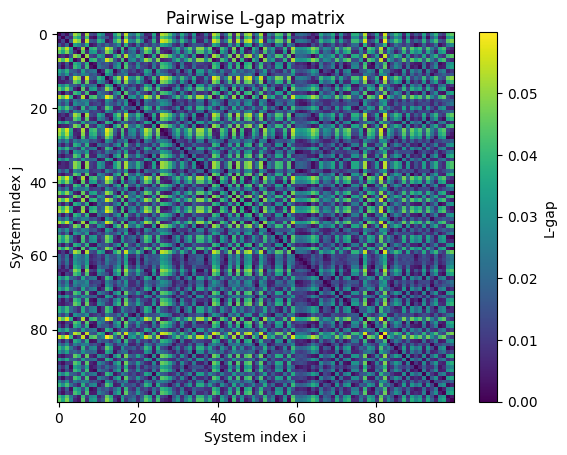

In [ ]:
plt.figure()
plt.imshow(D_l, interpolation="nearest", aspect="auto")
plt.colorbar(label="L-gap")
plt.title("Pairwise L-gap matrix")
plt.xlabel("System index i")
plt.ylabel("System index j")
# plt.savefig("heatmapL.png",dpi=300)
plt.show()

In [ ]:
#This gives the same result as the code below, but the code below is most tested so better use that.
def Gap_margin_from_K(K, C, y, H_system, L):
    K_prep = K @ np.linalg.pinv(C)     # shape (m, p)

    # Analytical finite-horizon basis for the C* object in [u,y] convention:
    Kbar_T = np.kron(np.eye(L), K_prep.T)   # (pL, mL)
    I_mL = np.eye(K_prep.shape[0] * L)      # (mL, mL)

    H_C_prep = np.vstack([I_mL, Kbar_T])    # [input; output]

    gap_val, _, _, _ = gapMetrics.Lgap_metric(
        H_system, H_C_prep, m, n, L, use_alt_formula=False
    )
    margin = 1.0 - gap_val

    return {"gap_to_C": gap_val, "margin": margin}

# for i in range(num_systems):
#     print("System", i)
#     K = LQR_wrapper(u, stored_x[i])
#     Hux = stored_hankels[i]
#     result = Gap_margin_from_K(K, C, stored_x[i], Hux, L)
    # print("Gap to C perp:", result["gap_to_C"])
    # print("Margin:", result["margin"])

# K = LQR_wrapper(u, stored_x[1])
# Hux = stored_hankels[1]
# result = Gap_margin_from_K(K, C, stored_x[1], Hux, L)
# # result = Gap_margin_from_K(K, C, u, Hux, L)
# print("Gap to C perp:", result["gap_to_C"])
# print("Margin:", result["margin"])

Gap to C perp: 0.9820028083882443
Margin: 0.017997191611755725


In [ ]:
def Gap_margin_from_K(K, C, y, H_system, L):
    K_prep = K @ np.linalg.pinv(C)     # shape (m, p), rough abserver
    #test if y is just random
    # T, p = y.shape
    # y = np.random.randn(T, 1)
    y = u
    # y = np.random.randn(*y.shape)  # shape (T, p)
    # print("K value:", K_prep)
    # print("y1:", y[1])

    u_ctrl = np.array([(K_prep.T @ y[i]).ravel() for i in range(y.shape[0])])
    #check data
    # print("y[1]:", (K_prep @ y[1].reshape(-1, 1)).ravel())
    # print("u_ctrl[1]:", u_ctrl[1])

    H_y_L = gapMetrics.hankel_matrix(y, L)
    H_u_L = gapMetrics.hankel_matrix(u_ctrl, L)

    H_C_prep = np.vstack([H_y_L, H_u_L])   # if graph convention is [y;u]
    # print("H_C_prep shape:", H_C_prep.shape)

    gap_val, _, _, _ = gapMetrics.Lgap_metric(H_system, H_C_prep, m, n, L, use_alt_formula=False)
    margin = 1.0 - gap_val

    return {"gap_to_C": gap_val, "margin": margin}

for i in range(num_systems):
    print("System", i)
    K = LQR_wrapper(u, stored_x[i])
    Hux = stored_hankels[i]
    # print("Hux shape:", Hux.shape)
    result = Gap_margin_from_K(K, C, stored_y[i], Hux, L)
    # print("Gap to C perp:", result["gap_to_C"])
    print("Margin:", result["margin"])

# K = LQR_wrapper(u, stored_x[1])
# Hux = stored_hankels[1]
# # result = Gap_margin_from_K(K, C, stored_x[1], Hux, L)
# result = Gap_margin_from_K(K, C, stored_y[1], Hux, L)
# # result = Gap_margin_from_K(K, C, u, Hux, L)
# print("Gap to C perp:", result["gap_to_C"])
# print("Margin:", result["margin"])

#to get gap between Gi and C:
# Gap_margin_from_K(K, C, stored_y[1i], Hux, L)["gap_to_C"]


System 0
y1: [0.56727808]
Margin: 0.010829737362150427
System 1
y1: [-0.30313316]
Margin: 0.01799719161175628
System 2
y1: [-1.20129782]
Margin: 0.010437023276295587
System 3
y1: [1.19344396]
Margin: 0.02149185758938177
System 4
y1: [-0.80826144]
Margin: 0.04934151704898093
System 5
y1: [-1.72759932]
Margin: 0.04179785010325432
System 6
y1: [0.42031102]
Margin: 0.015030985664922114
System 7
y1: [-0.07132427]
Margin: 0.04996427236510392
System 8
y1: [0.91625846]
Margin: 0.02063861675374512
System 9
y1: [0.30537743]
Margin: 0.02043135100070692
System 10
y1: [-0.01338342]
Margin: 0.03720943223651507
System 11
y1: [-2.68180188]
Margin: 0.028692407754025262
System 12
y1: [1.03149893]
Margin: 0.011660118850838619
System 13
y1: [-1.25645972]
Margin: 0.013023933046305003
System 14
y1: [1.1147913]
Margin: 0.036558764640838404
System 15
y1: [0.29562867]
Margin: 0.04100921837811655
System 16
y1: [-0.98654006]
Margin: 0.018544412113619346
System 17
y1: [0.04356142]
Margin: 0.05160642732828835
Syst

In [ ]:
def performance_degradation(delta, D12, u):
    # #Find the gap to C
    # delta = Gap_margin_from_K(K, C, y, Hux, L)["gap_to_C"]
    #D12 is the gap between leader and follower
    # e = np.linalg.norm(np.array([2,2]))
    e = np.linalg.norm(np.ones(10)) #this is hard coded, pls change according to other parts #For now it is a step change of 1
    step1 = np.sqrt(2 - (delta+D12)**2)
    # step1 = 1
    step2 = np.sqrt(1 - delta**2)
    step3 = np.sqrt(1 - (delta+D12)**2)
    bound = D12 * e * step1 / (step2 * step3)
    step4 = 1/step2 + 1/step3
    bound = bound * step4
    return bound

In [80]:
#best working method so far
def farthest_seeds(D, m, mode="min"):
    """
    pick m plants far apart.
    mode:
      - "avg": next seed maximizes average distance to existing plants
      - "min": next seed maximizes minimum distance to existing plants
    """
    N = D.shape[0]
    if m > N:
        raise ValueError("m cannot exceed number of plants")

    # First two: farthest pair
    i0, j0 = np.unravel_index(np.argmax(D), D.shape)
    seeds = [int(i0), int(j0)]

    while len(seeds) < m:
        candidates = [i for i in range(N) if i not in seeds]
        if mode == "avg":
            scores = [float(np.mean(D[i, seeds])) for i in candidates]
        elif mode == "min":
            scores = [float(np.min(D[i, seeds])) for i in candidates]
        else:
            raise ValueError("mode must be 'avg' or 'min'")
        seeds.append(int(candidates[int(np.argmax(scores))]))

    return seeds


def assign_by_smallest_group_average(D, seeds, order="hard_first"):
    """
    Incrementally assign remaining points.
    Each point is assigned to the group that yields smallest average distance to current members.
    """
    N = D.shape[0]
    groups = {s: [s] for s in seeds}  # key=seed id, value=list of members

    remaining = [i for i in range(N) if i not in seeds]

    if order == "hard_first":
        # points farthest from the seed set get assigned first
        seed_arr = np.array(seeds, dtype=int)
        d_to_seedset = np.min(D[:, seed_arr], axis=1)
        remaining.sort(key=lambda i: -d_to_seedset[i])
    elif order == "index":
        pass
    else:
        raise ValueError("order must be 'hard_first' or 'index'")

    for i in remaining:
        best_seed = None
        best_cost = np.inf
        for s, members in groups.items():
            cost = float(np.mean(D[i, members]))  # average distance to group members
            if cost < best_cost:
                best_cost = cost
                best_seed = s
        groups[best_seed].append(int(i))

    return groups  # dict(seed -> members)


def medoid_of_group(D, members):
    """
    Helper: choose leader as medoid (min sum distance within group).
    """
    members = np.array(members, dtype=int)
    subD = D[np.ix_(members, members)]
    k = int(np.argmin(subD.sum(axis=1)))
    return int(members[k])


def build_groups_and_check_thresholds(D, groups_dict):
    """
    Find leader, compute threshold, verify all within threshold.
    threshold_fn(members, leader) -> eps
      If None, eps is treated as +inf (no check).
    try_repair_leader:
      If True, and chosen medoid fails, try any member as leader that passes the threshold.
    """
    out = []
    well_pose = 1
    for seed, members in groups_dict.items():
        leader = medoid_of_group(D, members)
         
        K = LQR_wrapper(u, stored_x[leader])
        # print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        # eps = data_to_bpc(u, stored_x[leader], K)
        eps = Gap_margin_from_K(K, C, stored_x[leader], stored_hankels[leader], L)["margin"]
        # print("Threshold for leader", leader, ":", eps)
        dists = D[np.array(members, dtype=int), leader]

        ok = np.all(dists <= eps + 1e-12)

        # if (not ok) and try_repair_leader and threshold_fn is not None:
        #     # try to find any member that makes the group feasible
        #     repaired = False
        #     for cand in members:
        #         eps_c = float(threshold_fn(members, cand))
        #         if np.all(D[np.array(members, dtype=int), cand] <= eps_c + 1e-12):
        #             leader = int(cand)
        #             eps = eps_c
        #             repaired = True
        #             break
        #     ok = repaired

        if not ok:
            # provide a helpful error message
            # worst = float(np.max(dists))
            # raise ValueError(
            #     f"Threshold violation for group seeded by {seed}: "
            #     f"leader={leader}, eps={eps:.4g}, worst_dist={worst:.4g}, size={len(members)}"
            # )
            well_pose = 0

        out.append({"seed": int(seed), "leader": int(leader), "eps": float(eps), "members": [int(x) for x in members]})

    return out, well_pose


# ----- Full pipeline -----

def cluster_farthest_assign_medoid_threshold(D, m, seed_mode="min",
                                            assign_order="hard_first"):
    """
    Implements 3 steps:
      1) farthest m plants
      2) one-by-one assignment to smallest average distance group
      3) leader = medoid, check all within leader threshold
    """
    seeds = farthest_seeds(D, m, mode=seed_mode)
    groups_dict = assign_by_smallest_group_average(D, seeds, order=assign_order)
    groups = build_groups_and_check_thresholds(D, groups_dict)
    return groups


In [81]:
#grouping automatically
# groups, well_pose = cluster_farthest_assign_medoid_threshold(D_l, 5)
# print("well_pose:", well_pose)
for m in range(1, num_systems+1):
    print(f"Trying m={m} clusters...")
    groups, well_pose = cluster_farthest_assign_medoid_threshold(D_l, m, seed_mode="avg", assign_order="hard_first")
    if well_pose == 1:
        print(f"Successfully clustered with m={m} clusters.")
        break
for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
# print("groups:", groups)
# groups = [{"leader": c, "members": [...]}, ...]

N = D_l.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)
well_posed_beforet = np.zeros(N) #check before the last triangle inequality

for g in groups:
    leader = g["leader"]
    K = LQR_wrapper(u, stored_x[leader])
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D_l[leader, i]
        well_posed_beforet[i] = Gap_margin_from_K(K, C, stored_y[i], stored_hankels[i], L)["gap_to_C"]

print("range of well_posed_beforet:", np.min(well_posed_beforet), "to", np.max(well_posed_beforet))

Trying m=1 clusters...
y1: [-1.61403438]
y1: [0.12972819]
Successfully clustered with m=1 clusters.
leader: 87 size: 31 members: [12, 72, 9, 91, 16, 41, 1, 93, 97, 65, 70, 33, 78, 89, 23, 38, 87, 73, 13, 44, 25, 52, 36, 64, 35, 6, 0, 22, 59, 2, 81]
leader: 14 size: 69 members: [82, 18, 84, 68, 94, 29, 50, 21, 53, 11, 42, 67, 37, 19, 61, 71, 76, 60, 86, 32, 62, 34, 54, 88, 90, 80, 14, 3, 10, 92, 24, 66, 31, 69, 96, 83, 74, 8, 46, 75, 63, 57, 79, 30, 49, 95, 85, 20, 98, 56, 28, 55, 5, 58, 99, 15, 40, 43, 47, 27, 45, 4, 7, 51, 26, 48, 39, 17, 77]
y1: [0.90121013]
y1: [0.88890214]
y1: [-1.22246268]
y1: [-0.0114189]
y1: [-1.12060309]
y1: [-3.73599162]
y1: [0.64394101]
y1: [-0.70348874]
y1: [-2.47085932]
y1: [0.33091793]
y1: [1.51129274]
y1: [-1.20297149]
y1: [-0.75844428]
y1: [-0.75438211]
y1: [-0.80018031]
y1: [-1.78534009]
y1: [-1.42008799]
y1: [0.77830633]
y1: [3.2858093]
y1: [0.19313171]
y1: [1.17431891]
y1: [0.89938418]
y1: [-1.93357639]
y1: [0.61236978]
y1: [0.9140771]
y1: [-0.3943325

In [82]:
# import csv

with open("cluster_assignments.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    # header
    writer.writerow(["index", "leader", "dist_to_leader"])
    
    for i in range(N):
        writer.writerow([i, leader_of[i], dist_to_leader[i]])

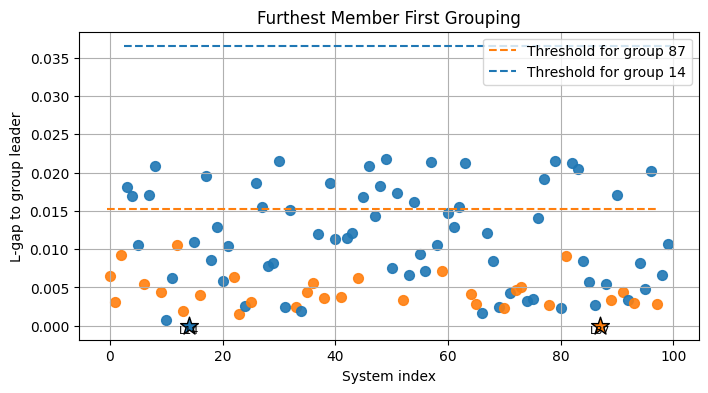

In [83]:
#plot scattered plot for auto clustering
plt.figure(figsize=(8, 4))

unique_leaders = sorted(set(leader_of))
colors = plt.cm.tab10(range(len(unique_leaders)))
leader_color = {l: colors[k] for k, l in enumerate(unique_leaders)}

for i in range(N):
    l = leader_of[i]
    if i == l:
        # leader: star marker
        plt.scatter(
            i,
            dist_to_leader[i],
            marker="*",
            s=180,
            color=leader_color[l],
            edgecolor="k",
            zorder=3,
        )
        plt.text(i, 0, f"L{l}", ha="center", va="top", fontsize=8)
    else:
        plt.scatter(
            i,
            dist_to_leader[i],
            color=leader_color[l],
            s=50,
            alpha=0.9,
        )

for g in groups:
    leader = g["leader"]
    members = g["members"]
    eps = g["eps"]
    plt.hlines(
        eps,
        xmin=min(members) - 0.5,
        xmax=max(members) + 0.5,
        colors=leader_color[leader],
        linestyles="--", 
        label=f"Threshold for group {leader}"
    )
    # for m in members:
    #     plt.hlines(
    #         y= 1 - well_posed_beforet[m],
    #         xmin=m - 0.3,
    #         xmax=m + 0.3,
    #         colors="green",
    #         alpha=0.9,
    #         # label=f"Group led by {leader}"
    #     )

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.xlabel("System index")
plt.ylabel("L-gap to group leader")
plt.title("Furthest Member First Grouping")
plt.grid(True)
plt.legend()
plt.savefig("ScatterPlot_for_2_clusters.png",dpi=300)
plt.show()


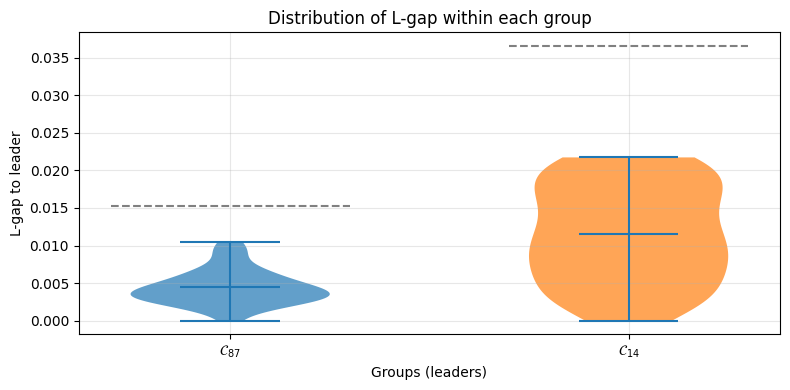

In [84]:
#violin plot for distribution of distances to leader within each group
group_data = []
labels = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    
    values = [dist_to_leader[i] for i in members]
    
    group_data.append(values)
    labels.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data, showmeans=True, showmedians=False)

# color each violin
unique_leaders = [g["leader"] for g in groups]
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# # optional: color mean lines
# for part in ("cbars", "cmins", "cmaxes", "cmeans"):
#     if part in vp:
#         vp[part].set_color("black")

#plot threshold lines for each group
for i, g in enumerate(groups, start=1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Groups (leaders)")
plt.ylabel("L-gap to leader")
plt.title("Distribution of L-gap within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def control_effectiveness(A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=50):
    """
    N is the number of steps to simulate.
    This is for performance degradation
    """
    x = init.copy()
    # x = np.array([0,0])
    total_error = 0.0
    Q = np.eye(2)
    R = np.eye(1) #TODO: can adapt to n change
    # R = np.zeros((1,1))
    N = 100
    for _ in range(N):
        # u = -K @ (x + 1 - goal) #For step d=1
        u = -K @ (x - goal)
        x = A @ x + B @ u
        # total_error += np.linalg.norm(x - goal) + np.linalg.norm(u)
        # total_error += np.linalg.norm(x - goal)
        e = x - goal
        total_error += e.T @ Q @ e + u.T @ R @ u
        # print(f"x: {x}, u: {u}, error: {total_error}")
        # print("e part:", e.T @ Q @ e, " u part:", u.T @ R @ u)
    return total_error

def control_effectiveness2(A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=10):
    """
    N is the number of steps to simulate.
    Also this is for performance difference
    """
    # x = init.copy()
    x = np.array([0,0])
    total_error = 0.0
    Q = np.eye(2)
    R = np.eye(1) #TODO: can adapt to n change
    for _ in range(N):
        u = -K @ (x + 1 - goal) #For step d=1
        # u = -K @ (x - goal)
        x = A @ x + B @ u
        # total_error += np.linalg.norm(x - goal) + np.linalg.norm(u)
        # total_error += np.linalg.norm(x - goal)
        e = x - goal
        total_error += e.T @ Q @ e + u.T @ R @ u
        # print(f"x: {x}, u: {u}, error: {total_error}")
        # print("e part:", e.T @ Q @ e, " u part:", u.T @ R @ u)
    return total_error

leader: 87 size: 31 members: [12, 72, 9, 91, 16, 41, 1, 93, 97, 65, 70, 33, 78, 89, 23, 38, 87, 73, 13, 44, 25, 52, 36, 64, 35, 6, 0, 22, 59, 2, 81]
leader: 14 size: 69 members: [82, 18, 84, 68, 94, 29, 50, 21, 53, 11, 42, 67, 37, 19, 61, 71, 76, 60, 86, 32, 62, 34, 54, 88, 90, 80, 14, 3, 10, 92, 24, 66, 31, 69, 96, 83, 74, 8, 46, 75, 63, 57, 79, 30, 49, 95, 85, 20, 98, 56, 28, 55, 5, 58, 99, 15, 40, 43, 47, 27, 45, 4, 7, 51, 26, 48, 39, 17, 77]


Text(0.5, 1.0, "Error under Leader's Controller")

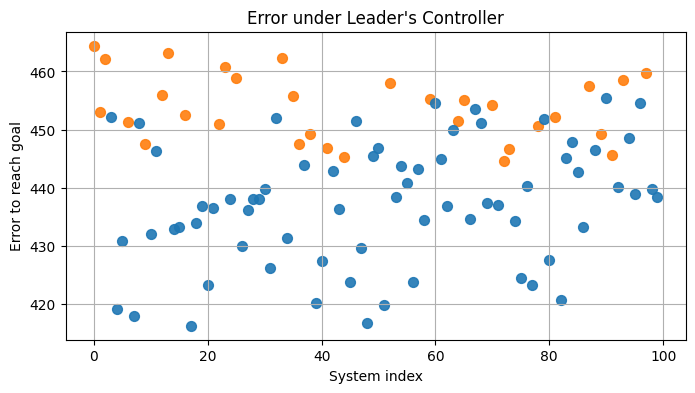

In [ ]:
#Get the cost to reach the goal under leader's controller for each system
error = {}

for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    error[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        error[m] = member_error

#plot errors
plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
        label=f"Group led by {leader}"
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error to reach goal")
plt.title("Error under Leader's Controller")   

leader: 87 size: 31 members: [12, 72, 9, 91, 16, 41, 1, 93, 97, 65, 70, 33, 78, 89, 23, 38, 87, 73, 13, 44, 25, 52, 36, 64, 35, 6, 0, 22, 59, 2, 81]
leader: 14 size: 69 members: [82, 18, 84, 68, 94, 29, 50, 21, 53, 11, 42, 67, 37, 19, 61, 71, 76, 60, 86, 32, 62, 34, 54, 88, 90, 80, 14, 3, 10, 92, 24, 66, 31, 69, 96, 83, 74, 8, 46, 75, 63, 57, 79, 30, 49, 95, 85, 20, 98, 56, 28, 55, 5, 58, 99, 15, 40, 43, 47, 27, 45, 4, 7, 51, 26, 48, 39, 17, 77]


Text(0.5, 1.0, 'Performance Difference')

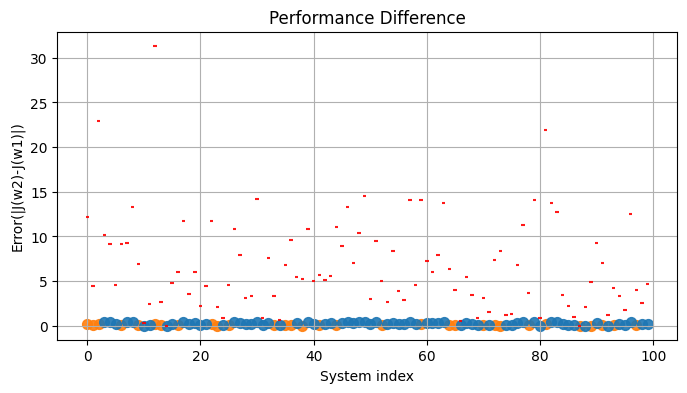

In [ ]:
#get the performance difference between leader and members, and compare with the bound
error_individual = {}
bound_individual = {}

for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    leader_error = control_effectiveness2(A_leader, B_leader, K_leader)
    error_individual[g["leader"]] = 0.0
    bound_individual[g["leader"]] = 0.0
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness2(A, B, K_leader)
        error_individual[m] = abs(member_error - leader_error)
        bound = performance_degradation((1-g["eps"]), D_l[g["leader"], m], u)
        # print(f"Dist to C: {g["eps"]}, dist to leader: {D_l[g['leader'], m]}")
        # bound = performance_degradation(D_l[g["leader"], m], stored_A[m], stored_B[m], K_leader)
        # print(f"System {m} error: {error_individual[m]}, bound: {bound}")
        bound_individual[m] = bound
#plot errors
plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error_individual[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
        label=f"Group led by {leader}"
    )
    for m in members:
        plt.hlines(
            y=bound_individual[m],
            xmin=m - 0.3,
            xmax=m + 0.3,
            colors="red",
            alpha=0.9,
            # label=f"Group led by {leader}"
        )
        if bound_individual[m] < error_individual[m]:
            print(f"Bound violation for system {m} in group led by {leader}: error={error_individual[m]:.4f}, bound={bound_individual[m]:.4f}")

plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error(|J(w2)-J(w1)|)")
plt.title("Performance Difference")   

In [88]:
with open("performance_difference_plot_data.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "method",
        "group_id",
        "leader",
        "member",
        "member_error_diff",
        "bound",
        "bound_violated",
    ])

    for group_id, g in enumerate(groups):
        leader = g["leader"]
        eps = g["eps"]

        K_leader = LQR_wrapper(u, stored_x[leader])
        A_leader = stored_A[leader]
        B_leader = stored_B[leader]
        leader_error = control_effectiveness2(A_leader, B_leader, K_leader)

        # leader row
        writer.writerow([
            "groups",
            group_id,
            leader,
            leader,
            0.0,
            0.0,
            False,
        ])

        # member rows
        for m in g["members"]:
            error_value = error_individual[m]
            bound_value = bound_individual[m]
            violated = bound_value < error_value

            writer.writerow([
                "groups",
                group_id,
                leader,
                m,
                error_value,
                bound_value,
                violated
            ])

C:\Users\Z PL\AppData\Local\Temp\ipykernel_46784\2481570110.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


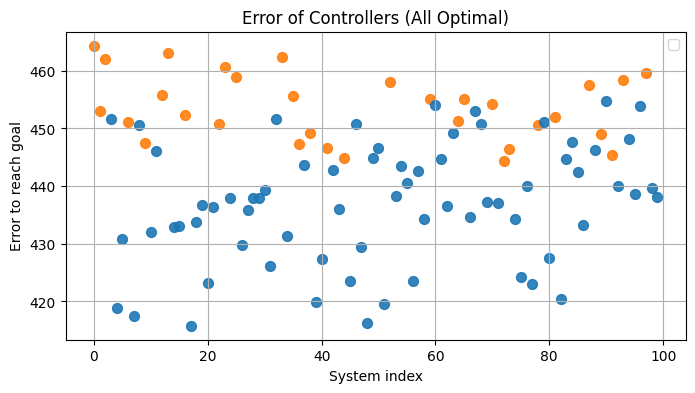

In [ ]:
#get the cost when all systems use their own optimal controller, which is the best performance they can achieve, to compare with the error under leader's controller
error_optimal = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error_o = control_effectiveness(A, B, K)
    error_optimal[i] = error_o

plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error_optimal[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error to reach goal")
plt.title("Error of Controllers (All Optimal)")
plt.legend()

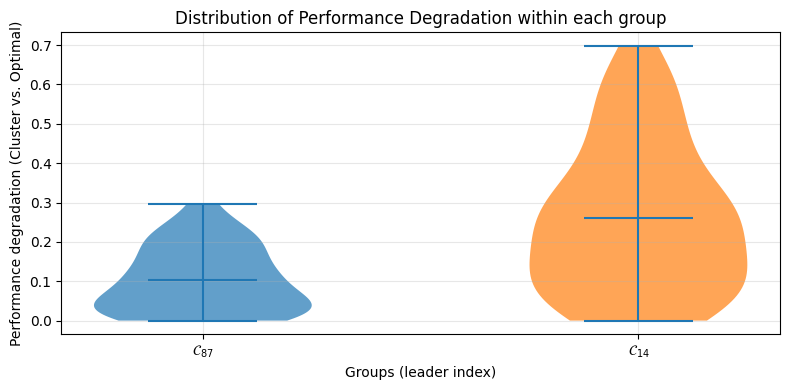

In [ ]:
#get the error of cost
delta_error = {i: error[i] - error_optimal[i] for i in range(num_systems)}

#violin plot
group_data_error = []
labels_error = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    
    values = [delta_error[i] for i in members]
    
    group_data_error.append(values)
    labels_error.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error, showmeans=True, showmedians=False)

# color each violin
unique_leaders = [g["leader"] for g in groups]
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels_error) + 1), labels_error)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Cluster vs. Optimal)")
plt.title("Distribution of Performance Degradation within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# import csv
# print(error)
with open("cluster_control_error.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # header
    writer.writerow(["index", "leader", "error", "error_optimal", "delta_error"])
    for i in range(N):
        writer.writerow([i, leader_of[i], error[i], error_optimal[i], delta_error[i]])

w shape: (100, 2)
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.        ]
 [0.16353329 0.99521279]] stored_B[7]: [[0.0441345 ]
 [0.00369232]]
stored_A[7]: [[0.96731881 0.

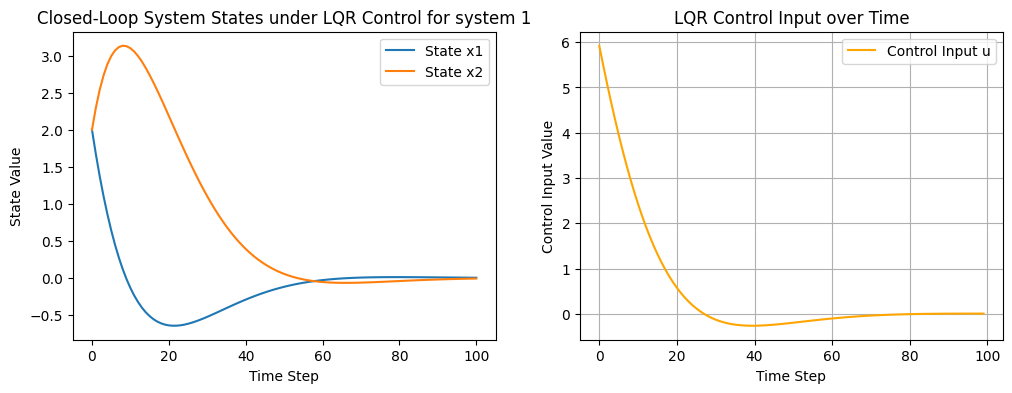

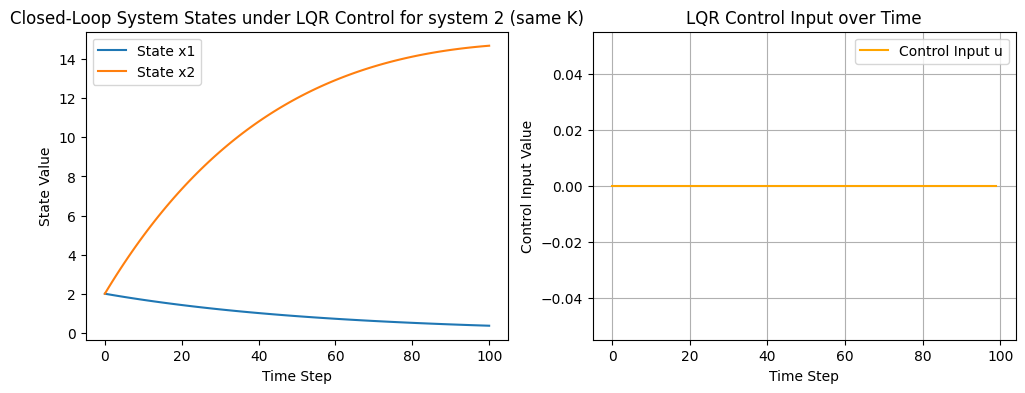

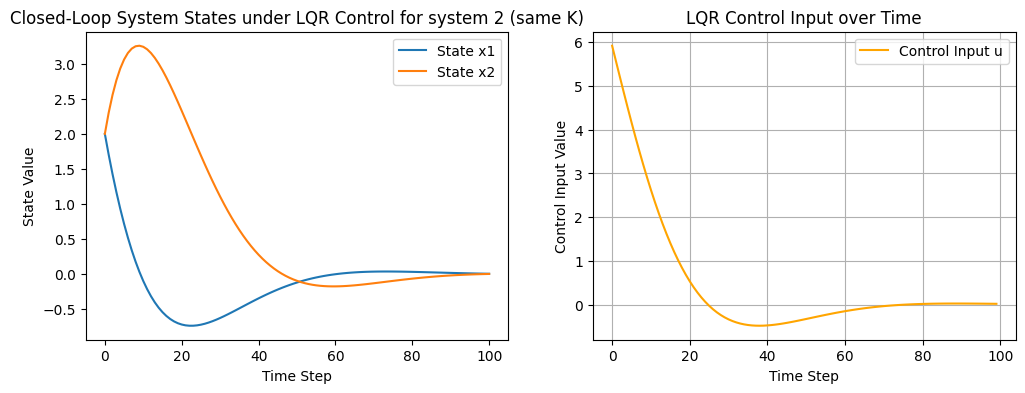

In [ ]:
#Get an exmaple run of sharing controller

#test whether the same controller can be used for 2 systems
#LQR controller
Q = np.eye(2)
# Q[1,1] = 0 #get rid of x2 penalty
R = np.eye(1)
T_d = 20  #data length for LQR

U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
X0 = stored_x[7][0:T_d, :].T # shape (n, T)  == X_{0,T}
X1 = stored_x[7][1:T_d+1, :].T # shape (n, T)  == X_{1,T}

# simulate closed loop system. Assumed using system 1 where A is a 2x2 matrix
N = 100 #number of control steps
#disturbance
w = np.random.randn(N, 2).reshape(-1, 2) * 0.1
print("w shape:", w.shape)

x0 = np.array([[2],[2]]) #initial state
x_cl = np.zeros((N+1, x0.shape[0], x0.shape[1]))
x_cl[0, :, :] = x0 #initial state
xf = np.array([[0],[0]]) #desired state
u_cl = np.zeros((N, R.shape[0], 1))
K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
# K_control = np.array([[2, 1]])  #test with wrong controller
# bias = np.array([[2.0], [2.0]])
bias = np.zeros((2,1))
# bias = 2

for k in range(N):
    u_control = -K_control @ (x_cl[k] + bias - xf) 
    # if k == 1:
    #     bias = np.array([[0.0], [0.0]])
        # bias = 0
    # u_control = np.zeros((1, 1))
    #add disturbance
    x_cl[k+1] = stored_A[7] @ x_cl[k] + stored_B[7] @ u_control
    print("stored_A[7]:", stored_A[7], "stored_B[7]:", stored_B[7])
    # x_cl[k+1] += w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 1')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#system 2 when there is no control, to see the difference
for k in range(N):
    # u_control = -K_op @ (x_cl[k] - xf)
    u_control = np.zeros((1, 1))
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#use same controller on system 2
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

y1: [1.37488061]
y1: [0.680926]
y1: [-0.06353701]
y1: [-1.56002789]
y1: [-0.48711101]
well_pose: 1


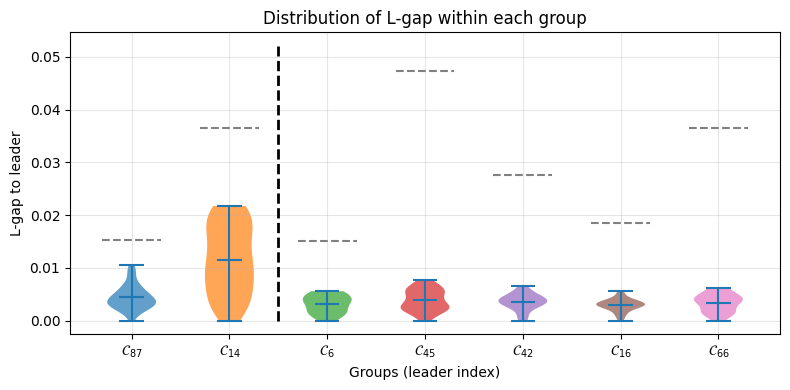

In [92]:
#grouping with specified m number of clusters
groupsm, well_posem = cluster_farthest_assign_medoid_threshold(D_l, 5)
print("well_pose:", well_posem)

N = D_l.shape[0]
leader_ofm = np.full(N, -1, dtype=int)
dist_to_leaderm = np.zeros(N)

for g in groupsm:
    leader = g["leader"]
    for i in g["members"]:
        leader_ofm[i] = leader
        dist_to_leaderm[i] = D_l[leader, i]

#violin plot for distribution of distances to leader within each group
# group_datam = []
# labelsm = []

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    
    values = [dist_to_leaderm[i] for i in members]
    
    group_data.append(values)
    labels.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data, showmeans=True, showmedians=False)

# color each violin
# unique_leaders = []
for g in groupsm:
    unique_leaders.append(g["leader"])
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# # optional: color mean lines
# for part in ("cbars", "cmins", "cmaxes", "cmeans"):
#     if part in vp:
#         vp[part].set_color("black")

#plot threshold lines for each group
for i, g in enumerate(groups, start=1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

plt.vlines(
    len(groups) + 0.5,
    ymin=0,
    ymax=max(g["eps"] for g in groupsm) * 1.1,
    colors="black",
    linestyles="--",
    linewidth=2.0,
    # label="Furthest Member First Thresholds"
)

for i, g in enumerate(groupsm, start=len(groups)+1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Groups (leader index)")
plt.ylabel("L-gap to leader")
plt.title("Distribution of L-gap within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("clustering_violin7.png",dpi=300)
plt.show()

In [93]:
#CSV for violin of both methods; clustering and eps

with open("group_violin_data.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    # header
    writer.writerow([
        "method",           # "groups" or "groupsm"
        "group_id",
        "leader",
        "member",
        "distance_to_leader",
        "threshold_eps"
    ])
    
    # --- original groups ---
    for group_id, g in enumerate(groups):
        leader = g["leader"]
        eps = g["eps"]
        
        for i in g["members"]:
            writer.writerow([
                "groups",
                group_id,
                leader,
                i,
                D_l[leader, i],
                eps
            ])
    
    # --- new groupsm ---
    for group_id, g in enumerate(groupsm):
        leader = g["leader"]
        eps = g["eps"]
        
        for i in g["members"]:
            writer.writerow([
                "groupsm",
                group_id,
                leader,
                i,
                dist_to_leaderm[i],
                eps
            ])

leader: 6 size: 15 members: [12, 25, 52, 44, 36, 64, 35, 6, 73, 0, 38, 22, 59, 2, 81]
leader: 45 size: 19 members: [82, 47, 27, 43, 40, 45, 15, 4, 7, 99, 58, 5, 51, 26, 48, 55, 39, 17, 77]
leader: 42 size: 21 members: [18, 54, 67, 68, 60, 62, 90, 32, 94, 84, 11, 50, 3, 76, 61, 19, 37, 42, 53, 29, 21]
leader: 16 size: 25 members: [72, 33, 13, 97, 23, 93, 96, 87, 65, 70, 46, 79, 8, 83, 89, 1, 16, 78, 63, 57, 30, 49, 9, 41, 91]
leader: 66 size: 20 members: [98, 88, 75, 20, 80, 31, 56, 34, 14, 86, 10, 92, 24, 66, 71, 69, 74, 95, 28, 85]


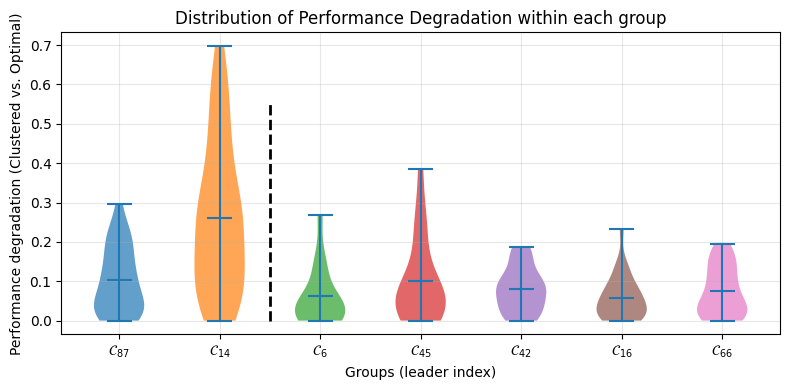

In [94]:
#proof of controllability (for adding 5)
    
errorm = {}

for g in groupsm:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    errorm[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        errorm[m] = member_error

error_optimalm = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error_o = control_effectiveness(A, B, K)
    error_optimalm[i] = error_o

delta_errorm = {i: errorm[i] - error_optimalm[i] for i in range(num_systems)}

#violin plot
# group_data_error = []
# labels_error = []

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    
    values = [delta_errorm[i] for i in members]
    
    group_data_error.append(values)
    labels_error.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error, showmeans=True, showmedians=False)

# color each violin
unique_leadersm = [g["leader"] for g in groupsm]
colors = plt.cm.tab10(range(len(unique_leadersm)+len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.vlines(
    len(groups) + 0.5,
    ymin=0.0,
    ymax=0.55,
    colors="black",
    linestyles="--",
    linewidth=2.0,
    label="Furthest Member First Thresholds"
)

plt.xticks(range(1, len(labels_error) + 1), labels_error)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Clustered vs. Optimal)")
plt.title("Distribution of Performance Degradation within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("error_violin7_op.png",dpi=300)
plt.show()

In [95]:
with open("performance_degradation_violin.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    writer.writerow([
        "method",          # "groups" or "groupsm"
        "group_id",
        "leader",
        "member",
        "delta_error",     # errorm - optimal
        "leader_error",    # error using leader K
        "optimal_error"    # error using own K
    ])
    
    # --- groups (old clustering) ---
    for group_id, g in enumerate(groups):
        leader = g["leader"]
        
        for i in g["members"]:
            writer.writerow([
                "groups",
                group_id,
                leader,
                i,
                delta_error[i],
                error[i],
                error_optimal[i]
            ])
    
    # --- groupsm (new clustering) ---
    for group_id, g in enumerate(groupsm):
        leader = g["leader"]
        
        for i in g["members"]:
            writer.writerow([
                "groupsm",
                group_id,
                leader,
                i,
                delta_errorm[i],
                errorm[i],
                error_optimalm[i]
            ])